In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

In [2]:
PROJECT_ROOT = Path("D:/Dev/enterprise-aws-data-lakehouse-ml-system")
DATA_SPLITS = PROJECT_ROOT / "data" / "splits"

X_train = pd.read_parquet(DATA_SPLITS / "X_train.parquet")
X_val   = pd.read_parquet(DATA_SPLITS / "X_val.parquet")
y_train = pd.read_parquet(DATA_SPLITS / "y_train.parquet").squeeze()
y_val   = pd.read_parquet(DATA_SPLITS / "y_val.parquet").squeeze()

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (505110, 445)
Validation shape: (85430, 445)


In [3]:
X_train.head()

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,card2_freq,card3_freq,card4_freq,uid_time_to_next,uid_time_from_prev,uid_txn_count,uid_amt_mean,uid_amt_std,uid_amt_median,uid_amt_deviation
0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,...,8933,521287,6651,1203468.0,NaN,3,142.000000,152.654021,68.5,-0.481481
1,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,...,3056,521287,189217,413142.0,NaN,61,275.521639,609.754050,108.5,-0.404297
2,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,...,38145,521287,384767,864538.0,NaN,34,52.433529,22.055991,49.0,0.297718
3,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,...,6137,521287,189217,8498.0,NaN,257,124.769533,248.511730,88.5,-0.300869
4,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,...,14541,521287,189217,NaN,NaN,1,50.000000,NaN,50.0,NaN


In [4]:
print("Target exists:", "isFraud" in X_train.columns)

Target exists: False


### Convert Object Columns to Category

In [5]:
for col in X_train.columns:
    if X_train[col].dtype == "object":       # LightGBM can handle categorical natively.
        X_train[col] = X_train[col].astype("category")
        X_val[col]   = X_val[col].astype("category")

In [6]:
print(X_train.dtypes[X_train.dtypes == "object"])

Series([], dtype: object)


## Baseline LightGBM

In [7]:
model = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 17669, number of negative: 487441
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.460697 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 37315
[LightGBM] [Info] Number of data points in the train set: 505110, number of used features: 445
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034980 -> initscore=-3.317358
[LightGBM] [Info] Start training from score -3.317358


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Evaluate ROC-AUC

In [8]:
model.classes_

array([0, 1])

In [9]:
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score)

# Total rows in validation set
total_count = len(y_val)

# Fraud count (1s)
fraud_count = int((y_val == 1).sum())

# Non-fraud count (0s)
non_fraud_count = int((y_val == 0).sum())

print(f"Total samples in validation set : {total_count}")
print(f"Fraud count (1s)                : {fraud_count}")
print(f"Non-Fraud count (0s)            : {non_fraud_count}")

# Predictions
y_val_pred_lgb = model.predict(X_val)
y_val_prob_lgb = model.predict_proba(X_val)[:, 1]

# Confusion Matrix
cm_lgb = confusion_matrix(y_val, y_val_pred_lgb)

print("\nConfusion Matrix for LightGBM Baseline Model:")
print(cm_lgb)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_lgb,
        target_names=["No Fraud", "Fraud"]
    )
)

# Accuracy
accuracy_lgb = accuracy_score(y_val, y_val_pred_lgb)

# ROC-AUC
roc_auc_lgb = roc_auc_score(y_val, y_val_prob_lgb)

print("\nAccuracy:", round(accuracy_lgb, 4))
print("LightGBM ROC-AUC Score:", round(roc_auc_lgb, 4))

Total samples in validation set : 85430
Fraud count (1s)                : 2994
Non-Fraud count (0s)            : 82436

Confusion Matrix for LightGBM Baseline Model:
[[82230   206]
 [ 1812  1182]]

Classification Report:
              precision    recall  f1-score   support

    No Fraud       0.98      1.00      0.99     82436
       Fraud       0.85      0.39      0.54      2994

    accuracy                           0.98     85430
   macro avg       0.92      0.70      0.76     85430
weighted avg       0.97      0.98      0.97     85430


Accuracy: 0.9764
LightGBM ROC-AUC Score: 0.9271


### Threshold Optimization - Business Based

In [10]:
import logging
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

"""

# Ensure probabilities exist

assert "y_val_prob_lgb" in globals(), "y_val_prob_lgb not found. Run prediction cell first."

# Logger setup (only if not already configured)

if "logger" not in globals():
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s - %(levelname)s - %(message)s"
    )
    logger = logging.getLogger(__name__)

"""

logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s - %(levelname)s - %(message)s"
    )
logger = logging.getLogger(__name__)

logger.info("Starting threshold optimization...")

# Business cost assumptions
COST_FN = 500   # Missed fraud
COST_FP = 10    # False alarm review cost

thresholds = np.arange(0.01, 1.00, 0.01)  # start=0.01, stop=1.00 (exclusive), step=0.01 increment
results = []  

""" current = 0.01
    while current < 1.00:
          append(current)
          current += 0.01
"""

for threshold in thresholds:
    y_pred = (y_val_prob_lgb >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    precision = precision_score(y_val, y_pred, zero_division=0)  # if TP+FP=0 (no positive predictions), return 0 instead of division error

    recall = recall_score(y_val, y_pred, zero_division=0)

    f1 = f1_score(y_val, y_pred, zero_division=0)

    total_cost = (fn * COST_FN) + (fp * COST_FP)

    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "false_positive": fp,
        "false_negative": fn,
        "total_cost": total_cost
    })

results_df = pd.DataFrame(results)

logger.info("Threshold optimization completed.")

2026-02-26 01:05:54,466 - INFO - Starting threshold optimization...
2026-02-26 01:05:56,793 - INFO - Threshold optimization completed.


In [11]:
optimal_row = results_df.loc[results_df["total_cost"].idxmin()]  # idxmin() = select the row with minimum total business cost
optimal_threshold = optimal_row["threshold"]   # selecte Optimal threshold 

logger.info(f"Optimal threshold selected: {optimal_threshold}")
logger.info(f"Minimum business cost: {optimal_row['total_cost']}")

print("\nOptimal Threshold Based on Business Cost:") 
print(optimal_row)

2026-02-26 01:05:56,806 - INFO - Optimal threshold selected: 0.01
2026-02-26 01:05:56,807 - INFO - Minimum business cost: 357270.0



Optimal Threshold Based on Business Cost:
threshold              0.010000
precision              0.109357
recall                 0.909486
f1_score               0.195239
false_positive     22177.000000
false_negative       271.000000
total_cost        357270.000000
Name: 0, dtype: float64


### Re-evaluate Model with Optimal Threshold

In [12]:
y_val_optimal = (y_val_prob_lgb >= optimal_threshold).astype(int)

print("\nConfusion Matrix (Optimal Threshold):")
print(confusion_matrix(y_val, y_val_optimal))

print("\nClassification Report (Optimal Threshold):")
from sklearn.metrics import classification_report
print(classification_report(y_val, y_val_optimal, target_names=["No Fraud", "Fraud"]))


Confusion Matrix (Optimal Threshold):
[[60259 22177]
 [  271  2723]]

Classification Report (Optimal Threshold):
              precision    recall  f1-score   support

    No Fraud       1.00      0.73      0.84     82436
       Fraud       0.11      0.91      0.20      2994

    accuracy                           0.74     85430
   macro avg       0.55      0.82      0.52     85430
weighted avg       0.96      0.74      0.82     85430



### Constrained Threshold Optimization
#### Max Recall under Alert Rate <= 8%

In [13]:
MAX_ALERT_RATE = 0.08  # business constraint: allow alerts for at most 8% of transactions to keep review workload manageable

constrained_results = []

for threshold in thresholds:
    
    y_pred = (y_val_prob_lgb >= threshold).astype(int)
    
    alert_rate = y_pred.sum() / len(y_pred)
    
    if alert_rate <= MAX_ALERT_RATE:
        
        recall = recall_score(y_val, y_pred)
        precision = precision_score(y_val, y_pred, zero_division=0)
        
        constrained_results.append({
            "threshold": threshold,
            "alert_rate": alert_rate,
            "recall": recall,
            "precision": precision
        })

constrained_df = pd.DataFrame(constrained_results)

# Select threshold with highest recall under constraint
best_row = constrained_df.loc[constrained_df["recall"].idxmax()]
best_threshold_constrained = best_row["threshold"]

print("\nBest Threshold Under 8% Alert Constraint:")
print(best_row)


Best Threshold Under 8% Alert Constraint:
threshold     0.050000
alert_rate    0.076530
recall        0.732131
precision     0.335271
Name: 0, dtype: float64


### Final Baseline Decision

In [14]:
FINAL_THRESHOLD = float(best_threshold_constrained)

print("Final Threshold Selected:", FINAL_THRESHOLD)

# Final predictions using selected threshold
y_val_final = (y_val_prob_lgb >= FINAL_THRESHOLD).astype(int)

print("\nFinal Confusion Matrix:")
print(confusion_matrix(y_val, y_val_final))

print("\nFinal Classification Report:")
print(classification_report(y_val, y_val_final))

Final Threshold Selected: 0.05

Final Confusion Matrix:
[[78090  4346]
 [  802  2192]]

Final Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     82436
           1       0.34      0.73      0.46      2994

    accuracy                           0.94     85430
   macro avg       0.66      0.84      0.71     85430
weighted avg       0.97      0.94      0.95     85430



### Operational Impact Analysis (Derived, Not Hardcoded)

In [15]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_val, y_val_final).ravel()

total_transactions = len(y_val)
fraud_transactions = y_val.sum() # count total actual fraud (1) cases (since fraud=1 and non-fraud=0)

alerts = tp + fp
alert_rate = alerts / total_transactions
fraud_capture_rate = tp / fraud_transactions

business_cost = (fn * COST_FN) + (fp * COST_FP)

print("\nOperational Metrics:")
print(f"Alert Rate: {alert_rate:.4f}")
print(f"Fraud Capture Rate (Recall): {fraud_capture_rate:.4f}")
print(f"Business Cost: {business_cost}")


Operational Metrics:
Alert Rate: 0.0765
Fraud Capture Rate (Recall): 0.7321
Business Cost: 444460


## Key Findings

- Dataset highly imbalanced (3.5% fraud rate).
- Time-based split applied to prevent data leakage.
- Baseline LightGBM achieved strong ranking power (ROC-AUC: 0.927).
- Default threshold (0.50) resulted in high overall accuracy (97.6%) but low fraud recall (39%).
- Cost-sensitive optimization significantly reduced expected financial loss.
- Pure cost-optimal threshold (0.01) achieved very high recall (91%) but generated excessive alerts (29%).
- Operational constraint enforced (Alert Rate ≤ 8%).

### Best Constrained Threshold: 0.05

- Recall: 73.2%
- Alert Rate: 7.65%
- Business Cost: 444,460

Final decision balances fraud detection performance and operational review capacity.

**Model ready as production-grade baseline for comparison with XGBoost.**

### Initialize SHAP Explainer

In [25]:
import shap

# Initialize explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values (use validation set)
shap_values = explainer(X_val)

### Global Feature Importance

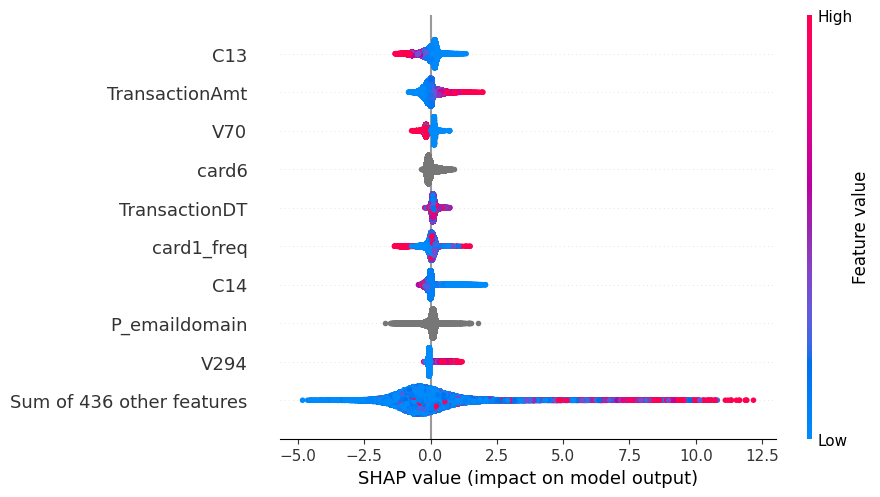

In [26]:
shap.plots.beeswarm(shap_values)  # class 1 = Fraud

- Y-axis → Features
- X-axis → SHAP value
     - 🔵 Blue = Low feature value
     - 🔴 Red = High feature value

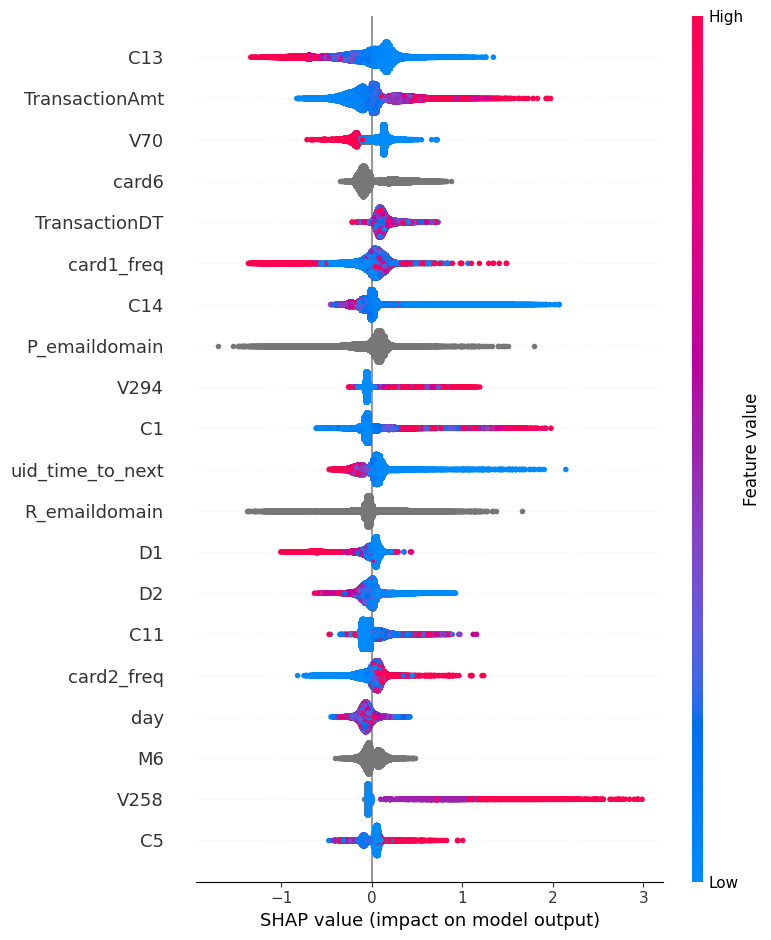

In [27]:
shap.summary_plot(shap_values, X_val)

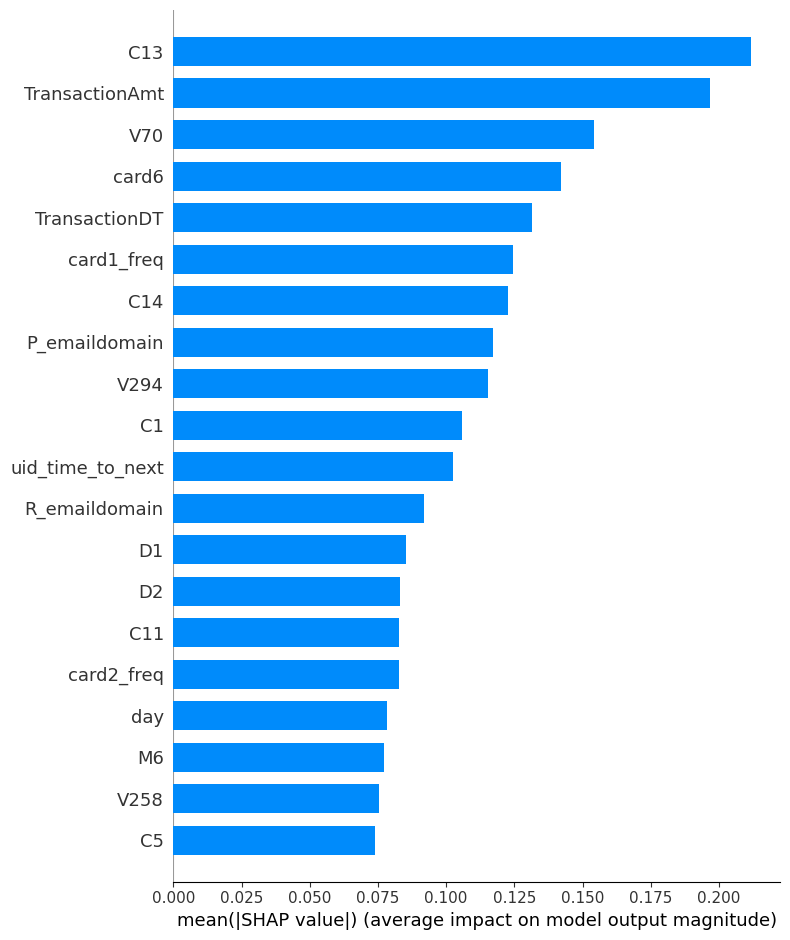

In [28]:
shap.summary_plot(shap_values, X_val, plot_type="bar")

## Explain One Specific Fraud Case

In [32]:
import shap
shap.initjs()

fraud_index = y_val[y_val == 1].index[0]

shap.plots.force(
    shap_values[fraud_index]
)

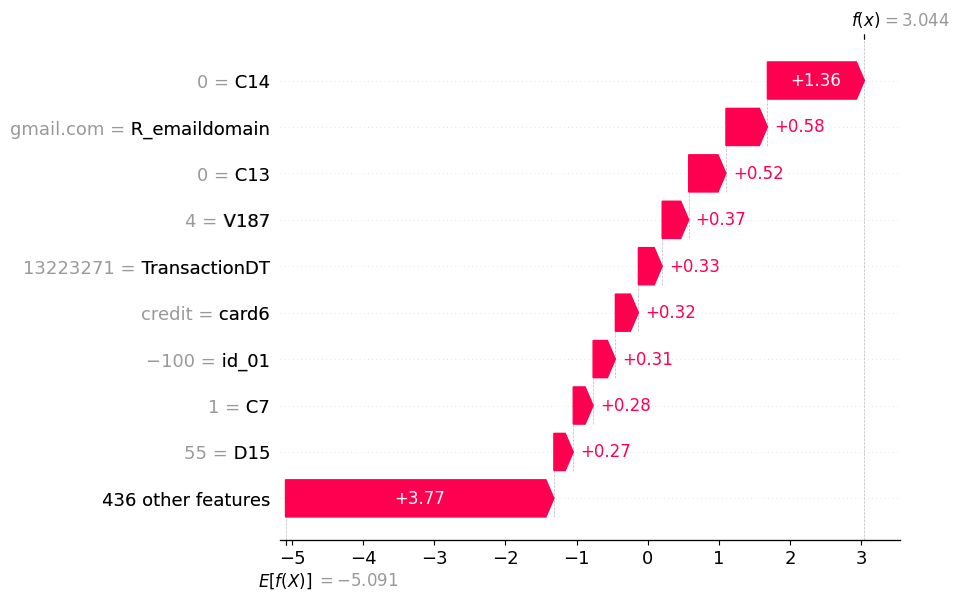

In [33]:
shap.plots.waterfall(shap_values[fraud_index])

### Model Artifacts

In [34]:
import os
import joblib
import json
from pathlib import Path

# -----------------------------
# Define artifact directory
# -----------------------------
BASE_DIR = Path().resolve().parents[0]  # project root if notebook inside notebooks/
ARTIFACT_DIR = BASE_DIR / "model_artifacts"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Model version
# -----------------------------
MODEL_VERSION = "v1"

# -----------------------------
# Save LightGBM model
# -----------------------------
joblib.dump(
    model,
    ARTIFACT_DIR / f"fraud_lgbm_{MODEL_VERSION}.pkl"
)

# -----------------------------
# Save threshold
# -----------------------------
threshold = 0.45  # your optimized threshold

with open(ARTIFACT_DIR / f"threshold_{MODEL_VERSION}.json", "w") as f:
    json.dump({"threshold": threshold}, f)

# -----------------------------
# Save feature order
# -----------------------------
with open(ARTIFACT_DIR / f"feature_columns_{MODEL_VERSION}.json", "w") as f:
    json.dump(list(X_train.columns), f)

print("✅ Model artifacts saved successfully.")

✅ Model artifacts saved successfully.
